# RoPE (Rotary Positional Encoding) Graphs

This notebook visualizes how RoPE rotates embedding pairs by position and why attention similarity becomes a function of relative position.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def rope_inv_freq(d_model, theta_base=10000.0):
    if d_model % 2 != 0:
        raise ValueError('RoPE expects an even embedding dimension.')
    pair_idx = np.arange(0, d_model, 2, dtype=np.float64)
    return theta_base ** (-pair_idx / d_model)


def rope_angles(seq_len, d_model, theta_base=10000.0):
    pos = np.arange(seq_len, dtype=np.float64)[:, None]
    inv_freq = rope_inv_freq(d_model, theta_base)[None, :]
    return pos * inv_freq  # (seq_len, d_model // 2)


def apply_rope(x, positions, theta_base=10000.0):
    # x: (T, D), positions: (T,)
    t, d = x.shape
    if d % 2 != 0:
        raise ValueError('RoPE expects an even embedding dimension.')
    if positions.shape[0] != t:
        raise ValueError('positions length must match x.shape[0].')

    inv_freq = rope_inv_freq(d, theta_base)
    angles = positions[:, None].astype(np.float64) * inv_freq[None, :]
    c = np.cos(angles)
    s = np.sin(angles)

    x_even = x[:, 0::2]
    x_odd = x[:, 1::2]

    out = np.empty_like(x, dtype=np.float64)
    out[:, 0::2] = x_even * c - x_odd * s
    out[:, 1::2] = x_even * s + x_odd * c
    return out

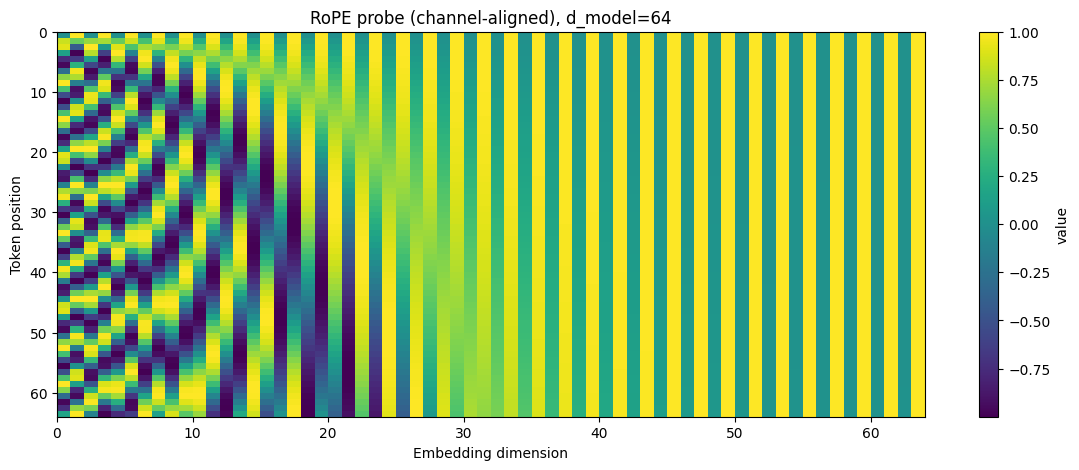

In [3]:
# Single RoPE probe plot at 64 dimensions.
seq_len = 64
d_model = 64
theta_base = 10000.0
d_model_probe = d_model
positions = np.arange(seq_len, dtype=np.float64)

probe_plot = np.zeros((seq_len, d_model_probe), dtype=np.float64)
probe_plot[:, 0::2] = 1.0
rope_probe_plot = apply_rope(probe_plot, positions, theta_base)

# Align pair channels to (sin, cos) ordering used in APE-style heatmaps.
rope_probe_plot_aligned = np.empty_like(rope_probe_plot)
rope_probe_plot_aligned[:, 0::2] = rope_probe_plot[:, 1::2]
rope_probe_plot_aligned[:, 1::2] = rope_probe_plot[:, 0::2]

plt.figure(figsize=(14, 5))
plt.pcolormesh(rope_probe_plot_aligned, cmap='viridis')
plt.title('RoPE probe (channel-aligned), d_model=64')
plt.xlabel('Embedding dimension')
plt.ylabel('Token position')
plt.xlim((0, d_model_probe))
plt.ylim((seq_len, 0))
plt.colorbar(label='value')
plt.show()

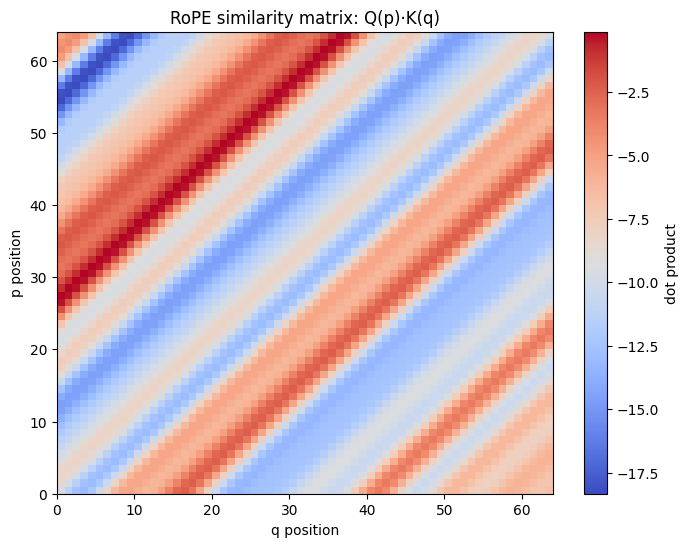

In [4]:
# Relative-position behavior: Q(p)·K(q) depends on (p - q).
rng = np.random.default_rng(0)
q0 = rng.normal(size=(d_model,)).astype(np.float64)
k0 = rng.normal(size=(d_model,)).astype(np.float64)

positions = np.arange(seq_len, dtype=np.float64)
Q = np.repeat(q0[None, :], seq_len, axis=0)
K = np.repeat(k0[None, :], seq_len, axis=0)
Q_rot = apply_rope(Q, positions, theta_base)
K_rot = apply_rope(K, positions, theta_base)
sim = Q_rot @ K_rot.T

plt.figure(figsize=(8, 6))
plt.pcolormesh(sim, cmap='coolwarm')
plt.title('RoPE similarity matrix: Q(p)·K(q)')
plt.xlabel('q position')
plt.ylabel('p position')
plt.colorbar(label='dot product')
plt.show()


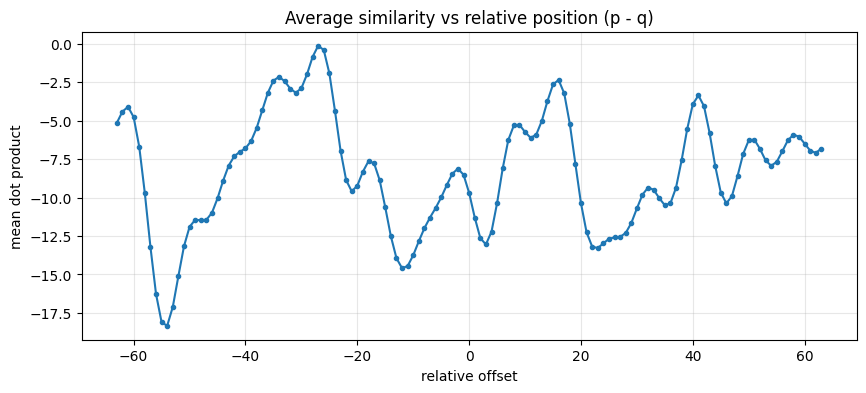

In [5]:
# Collapse by relative offset to show Toeplitz structure.
offsets = np.arange(-(seq_len - 1), seq_len)
offset_means = np.array([np.mean(np.diag(sim, k=o)) for o in offsets])

plt.figure(figsize=(10, 4))
plt.plot(offsets, offset_means, marker='o', markersize=3)
plt.title('Average similarity vs relative position (p - q)')
plt.xlabel('relative offset')
plt.ylabel('mean dot product')
plt.grid(alpha=0.3)
plt.show()